# VedaVision — Deep Learning Benchmark (Species-ID)

**Purpose of this notebook:** this is NOT a replacement for the handcrafted botanical
feature + RF/SVM/HGB ensemble (that remains the primary Module 3 system). This is a
**controlled ablation benchmark** — a CNN transfer-learning baseline trained and
evaluated with *the exact same discipline* as the handcrafted pipeline
(leaf-level grouped split, `test_` files frozen and touched once, honest CV),
so that any accuracy gap (or lack of one) between DL and handcrafted features is a
fair, defensible comparison for the dissertation/viva — not an artifact of leakage.

**Two-stage transfer learning (per supervisor's suggestion):**
1. Stage 0 (optional, recommended if time allows) — fine-tune an ImageNet backbone on a
   large **public leaf dataset** (domain adaptation: ImageNet → "leaf domain").
2. Stage 1 — fine-tune that leaf-adapted backbone on the small VedaVision 12-species
   compound-leaf dataset (leaf domain → VedaVision domain).

If Stage 0 is skipped due to time, going straight ImageNet → VedaVision (Stage 1 only)
is still valid transfer learning — just weaker domain adaptation. Both paths are coded
below; toggle `USE_STAGE0`.

Run this top-to-bottom in Colab/Jupyter with a GPU if possible (CPU works but is slow).


In [1]:
# ------------------------------------------------------------------
# OPTIONAL — run this cell FIRST if you hit:
#   AttributeError: module 'keras' has no attribute 'KerasTensor'
# This is a TF/Keras version-mismatch in your venv (TF >=2.16 expects Keras 3, but an
# incompatible standalone `keras` package is shadowing it). Forcing legacy Keras 2 sidesteps
# it without needing to align exact version numbers.
#
# One-time setup in PowerShell (venv activated): pip install tf-keras
# Then run this cell, RESTART THE KERNEL, and re-run the notebook from the top —
# the env var only takes effect on a fresh `import tensorflow`.
# ------------------------------------------------------------------
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"


In [2]:
# ------------------------------------------------------------------
# 0. Config — EDIT THESE PATHS
# ------------------------------------------------------------------
import os, random, json
import numpy as np
import tensorflow as tf
from pathlib import Path

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# Root of your species-ID dataset, same convention as preprocessing/species_id/batch_processor.py
# Resolve it robustly whether the kernel starts in the repo root or in notebooks/.
for base_dir in [Path.cwd(), Path.cwd().parent]:
    candidate_root = base_dir / "processed" / "images"
    if candidate_root.exists():
        DATA_ROOT = candidate_root
        break
else:
    raise FileNotFoundError(
        "Could not find processed/images. Checked: "
        f"{Path.cwd() / 'processed' / 'images'} and {Path.cwd().parent / 'processed' / 'images'}. "
        "Edit DATA_ROOT above manually if your layout differs."
    )
print("DATA_ROOT resolved to:", DATA_ROOT)

IMG_SIZE  = (224, 224)
BATCH_SIZE = 16
N_CLASSES  = 12

# Public leaf dataset for Stage 0 domain-adaptation pretraining (optional).
# Using Kaggle "hafizaaaizamalik/leaf-types-image-dataset-for-classification" —
# downloaded and prepared in Section 4 below. Leave False to skip Stage 0 entirely.
USE_STAGE0 = False

OUTPUT_DIR = Path("dl_benchmark_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)



DATA_ROOT resolved to: d:\Desktop\UoM\Academic\FYP\ayurveda-recognition\model_training\module_3\processed\images


## 1. Build the file index — mirrors `model_training.py` split logic

Same rules as the handcrafted pipeline (see `VedaVision_Memory.md` §3):
- filename starts with `test_` → test set, **never augmented, touched once**
- everything else → train pool
- `leaf_id` (derived from filename, same physical leaf photographed top+bottom) is the
  **group key** — a leaf's top and bottom images must never be split across train/val folds.


In [3]:
import pandas as pd

def index_dataset(root: Path):
    rows = []
    for species_dir in sorted(root.iterdir()):
        if not species_dir.is_dir():
            continue
        species = species_dir.name
        for view in ["top", "bottom"]:
            view_dir = species_dir / view
            if not view_dir.exists():
                continue
            # Prefer masked_raw (fairest comparison, matches handcrafted pipeline's input),
            # fall back to enhanced, then the view folder itself — whichever exists first.
            image_dirs = [view_dir / "masked_raw", view_dir / "enhanced", view_dir]
            for image_dir in image_dirs:
                if not image_dir.exists():
                    continue
                image_paths = sorted(image_dir.rglob("*.jpg"))
                if not image_paths:
                    continue
                for img_path in image_paths:
                    fname = img_path.name
                    is_test = fname.startswith("test_")
                    # leaf_id: strip test_ prefix and extension so top/bottom of the same
                    # physical leaf share a group key, e.g. test_001.jpg -> "001"
                    leaf_id = fname.replace("test_", "").rsplit(".", 1)[0]
                    rows.append({
                        "path": str(img_path),
                        "species": species,
                        "view": view,
                        "is_test": is_test,
                        "leaf_id": f"{species}_{leaf_id}",   # unique across species
                    })
                break   # stop at first matching subfolder for this view
    return pd.DataFrame(rows)

df = index_dataset(DATA_ROOT)
print(df.shape)
print(df.groupby(["species", "is_test"]).size().unstack(fill_value=0))

train_pool = df[~df.is_test].reset_index(drop=True)
test_df    = df[df.is_test].reset_index(drop=True)
print(f"train pool: {len(train_pool)} images | sealed test: {len(test_df)} images")


(1391, 5)
is_test            False  True 
species                        
beli                  96     20
kalawal               96     20
kasthuri_dehi         96     20
kathurupila           96     20
kattakumanjal         96     20
maha_undupiyaliya     96     20
nil_awariya           96     20
ranawara              97     20
siymbala              96     20
thunpath_kurundu      94     20
wal_bilin             96     20
wal_kollu             96     20
train pool: 1151 images | sealed test: 240 images


## 2. Leaf-level grouped train/val split

Same principle as `StratifiedGroupKFold(image_path)` in the handcrafted pipeline — here
we do a single grouped train/val split (simpler than full k-fold for a DL notebook under
time pressure), grouped by `leaf_id` so top/bottom of one leaf never straddle the split.

If you want a CV-style estimate instead of one split, wrap this in a loop over
`StratifiedGroupKFold` exactly like `model_training.py` does — same idea, just re-run
Stage 1 fine-tuning per fold. Given the deadline, one grouped split + the frozen sealed
test is the pragmatic choice.


In [4]:
from sklearn.model_selection import StratifiedGroupKFold

le_species = sorted(df.species.unique())
species_to_idx = {s: i for i, s in enumerate(le_species)}
train_pool["y"] = train_pool.species.map(species_to_idx)

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
train_idx, val_idx = next(sgkf.split(train_pool, train_pool.y, groups=train_pool.leaf_id))
tr_df = train_pool.iloc[train_idx].reset_index(drop=True)
va_df = train_pool.iloc[val_idx].reset_index(drop=True)

# sanity check: no leaf_id leakage between train and val
assert set(tr_df.leaf_id) & set(va_df.leaf_id) == set()
print(f"train: {len(tr_df)}  val: {len(va_df)}")


train: 921  val: 230


## 3. tf.data pipelines

Augmentation intentionally mirrors `preprocessing/shared/augmentation.py`'s **exclusions**
(no CoarseDropout / RandomCrop-style destructive ops, no strong colour shifts) so the DL
run isn't given an unfair augmentation budget the handcrafted pipeline didn't have —
that would bias the comparison in DL's favour for the wrong reason.


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    img = tf.clip_by_value(img, 0.0, 255.0)
    return img, label

def make_dataset(frame, training):
    paths = frame.path.values
    labels = frame.y.values if "y" in frame else frame.species.map(species_to_idx).values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(len(frame), seed=SEED)
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(tr_df, training=True)
val_ds   = make_dataset(va_df, training=False)

test_df["y"] = test_df.species.map(species_to_idx)
test_ds  = make_dataset(test_df, training=False)   # built now, not touched until Section 6


In [6]:
# ------------------------------------------------------------------
# build_backbone() is defined here — BEFORE Section 4 — and always runs, so Stage 1
# (Section 5) works whether or not you run the Stage 0 cells below. Skipping Stage 0
# means skipping ALL of Section 4's cells (or just leaving USE_STAGE0 = False), not just
# the training cell — either way this cell still needs to run once.
# ------------------------------------------------------------------
def build_backbone(input_shape=(224, 224, 3)):
    base = tf.keras.applications.MobileNetV2(
        input_shape=input_shape, include_top=False, weights="imagenet"
    )
    return base

stage0_weights_path = OUTPUT_DIR / "stage0_backbone.weights.h5"


## 4. Stage 0 — domain-adapt ImageNet backbone on a small public leaf-type dataset (optional)

**Dataset (switched from the ImageCLEF one):**
[`hafizaaaizamalik/leaf-types-image-dataset-for-classification`](https://www.kaggle.com/datasets/hafizaaaizamalik/leaf-types-image-dataset-for-classification)
— 28 MB, 5 folders, ~200 images total: **Simple Leaf, Compound Leaf, Needle-like Leaf,
Scale-like Leaf, Broad Leaf**. Plain folder-per-class layout (`jpg`/`jpeg`/`webp`), no XML
— much simpler to wire up than the ImageCLEF set, and it downloads in seconds.

**This is actually a better-targeted Stage 0 task than the species dataset was, not just a
smaller/faster one.** The earlier ImageCLEF plan used *species* as the Stage 0 pretext
task, which only teaches "leaf-like" low-level statistics as a side effect of learning
irrelevant species labels. This dataset's 5 classes directly include **Compound Leaf vs
Simple Leaf** as the label — so the Stage 0 pretext task here is learning to tell compound
leaves apart from simple/needle/scale/broad leaves, which is a much closer match to what
you actually want the backbone nudged toward before it ever sees your 12 compound species.

**The honest caveat to write in the dissertation:** ~40 images/class is very small — nowhere
near enough to reliably learn "compound-leaf-ness" in a way that generalizes across the huge
visual diversity compound leaves take (rose vs neem vs moringa look very different despite
all being compound). Treat Stage 0 here as a *weak prior*, not real domain mastery, and say
so plainly rather than overclaiming what 200 images bought you. Given that, this notebook:
- keeps the backbone **frozen for all of Stage 0** (head-only training) — unfreezing and
  fine-tuning deep layers on ~200 images risks overfitting to this dataset's specific photo
  style (backgrounds, lighting, watermarks) rather than learning anything generalizable,
- uses strong augmentation and few epochs with early stopping,
- Stage 1 (Section 5) still does the real fine-tuning work on your actual data regardless.

If you'd rather skip Stage 0 entirely given how weak this signal necessarily is, `USE_STAGE0 = False` in the config cell is a completely reasonable call too — say so in the write-up as a considered choice, not a shortcut.


In [ ]:
# ------------------------------------------------------------------
# 4a. Download and inspect folder structure
# ------------------------------------------------------------------
import kagglehub

PUBLIC_DATA_ROOT = kagglehub.dataset_download(
    "hafizaaaizamalik/leaf-types-image-dataset-for-classification"
)
PUBLIC_DATA_ROOT = Path(PUBLIC_DATA_ROOT)
print("Downloaded to:", PUBLIC_DATA_ROOT)

for p in sorted(PUBLIC_DATA_ROOT.rglob("*")):
    if p.is_dir():
        n_imgs = len(list(p.glob("*.jpg"))) + len(list(p.glob("*.jpeg"))) + len(list(p.glob("*.webp")))
        if n_imgs > 0:
            print(f"{str(p.relative_to(PUBLIC_DATA_ROOT)):45s} {n_imgs} images")


In [ ]:
# ------------------------------------------------------------------
# 4b. Build the Stage 0 dataset — folder-per-class, so image_dataset_from_directory
#     works directly (it loads via PIL under the hood, so webp is fine alongside jpg/jpeg)
# ------------------------------------------------------------------
# If the printed tree above shows the 5 class folders nested one level deeper than
# PUBLIC_DATA_ROOT (e.g. PUBLIC_DATA_ROOT/some_subfolder/Compound Leaf/*.jpg), point
# LEAF_TYPE_ROOT at that subfolder instead — this is the one thing worth eyeballing
# against the printed tree before running the rest.
LEAF_TYPE_ROOT = PUBLIC_DATA_ROOT   # <-- EDIT if class folders are nested one level deeper

public_train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    LEAF_TYPE_ROOT, image_size=IMG_SIZE, batch_size=16, seed=SEED,
    validation_split=0.15, subset="training", label_mode="int"
)
public_val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    LEAF_TYPE_ROOT, image_size=IMG_SIZE, batch_size=16, seed=SEED,
    validation_split=0.15, subset="validation", label_mode="int"
)
n_public_classes = len(public_train_ds_raw.class_names)
print("Classes found:", public_train_ds_raw.class_names)

stage0_augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.1),
])

public_train_ds = public_train_ds_raw.map(
    lambda x, y: (stage0_augment(x, training=True), y), num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)
public_val_ds = public_val_ds_raw.prefetch(AUTOTUNE)


In [ ]:
if USE_STAGE0:
    base = build_backbone()
    base.trainable = False   # frozen for all of Stage 0 — see rationale above (tiny dataset)

    stage0_model = tf.keras.Sequential([
        tf.keras.layers.Rescaling(1./127.5, offset=-1),
        base,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(n_public_classes, activation="softmax"),
    ])
    stage0_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                          loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    stage0_model.fit(
        public_train_ds, validation_data=public_val_ds, epochs=15,
        callbacks=[tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=4, restore_best_weights=True)]
    )

    base.save_weights(str(stage0_weights_path))
    print("Stage 0 backbone saved ->", stage0_weights_path)
else:
    print("Skipping Stage 0 — Stage 1 will start from plain ImageNet weights.")


## 5. Stage 1 — fine-tune on the VedaVision 12-species train set

Two-phase fine-tuning (standard transfer-learning recipe):
1. Freeze backbone, train only the new classification head (few epochs, higher LR).
2. Unfreeze the top N backbone layers, fine-tune the whole thing at a low LR with
   early stopping on the held-out **validation** fold (never the sealed test).

Class weights compensate for any species-count imbalance in the train pool.


In [7]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.arange(N_CLASSES)
weights = compute_class_weight("balanced", classes=classes, y=tr_df.y.values)
class_weight = dict(zip(classes, weights))

base = build_backbone()
if USE_STAGE0 and stage0_weights_path.exists():
    base.load_weights(str(stage0_weights_path))
    print("Loaded Stage 0 leaf-domain-adapted weights.")

base.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.layers.Rescaling(1./127.5, offset=-1)(inputs)
x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.4)(x)
outputs = tf.keras.layers.Dense(N_CLASSES, activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
]

# Phase A — head only
history_a = model.fit(train_ds, validation_data=val_ds, epochs=15,
                       class_weight=class_weight, callbacks=callbacks)

phase_a_weights = OUTPUT_DIR / "phase_a_weights.weights.h5"
model.save_weights(str(phase_a_weights))




Epoch 1/15


58/58 [==============================] - 39s 449ms/step - loss: 1.7014 - accuracy: 0.4148 - val_loss: 0.7884 - val_accuracy: 0.7957 - lr: 0.0010
Epoch 2/15
58/58 [==============================] - 26s 434ms/step - loss: 0.7956 - accuracy: 0.7101 - val_loss: 0.5116 - val_accuracy: 0.8565 - lr: 0.0010
Epoch 3/15
58/58 [==============================] - 26s 429ms/step - loss: 0.5715 - accuracy: 0.8035 - val_loss: 0.4174 - val_accuracy: 0.8826 - lr: 0.0010
Epoch 4/15
58/58 [==============================] - 32s 535ms/step - loss: 0.4517 - accuracy: 0.8491 - val_loss: 0.3633 - val_accuracy: 0.9000 - lr: 0.0010
Epoch 5/15
58/58 [==============================] - 28s 469ms/step - loss: 0.3683 - accuracy: 0.8903 - val_loss: 0.3399 - val_accuracy: 0.9043 - lr: 0.0010
Epoch 6/15
58/58 [==============================] - 41s 651ms/step - loss: 0.3073 - accuracy: 0.9066 - val_loss: 0.2820 - val_accuracy: 0.9261 - lr: 0.0010
Epoch 7/15
58/58 [==============================] - 35s 560m

### 5b. Unfreeze-depth / learning-rate sweep — selected on val only

This directly answers "did you just pick a config that makes DL lose?" — every trial
below is scored on `val_ds` (never the sealed test), and the config with the best val
accuracy is what actually gets used for the real fine-tuning run in the next cell. The
result table is worth keeping as a dissertation appendix/artifact: it's the evidence that
Phase B's "unfreeze top 30 layers, LR 1e-5" wasn't an arbitrary or self-serving choice —
it's whatever this sweep says is best, and if a different config wins, that's what runs.


In [9]:
sweep_configs = [
    {"unfreeze_layers": 0,    "lr": None},   # baseline: keep Phase A's head-only weights, no further fine-tuning
    {"unfreeze_layers": 30,   "lr": 1e-5},
    {"unfreeze_layers": 30,   "lr": 1e-4},
    {"unfreeze_layers": 60,   "lr": 1e-5},
    {"unfreeze_layers": None, "lr": 1e-5},   # None = unfreeze the ENTIRE backbone
]

SWEEP_EPOCHS = 6   # short budget per trial — this is a selection sweep, not final training

sweep_results = []
for cfg in sweep_configs:
    model.load_weights(str(phase_a_weights))
    if cfg["unfreeze_layers"] == 0:
        base.trainable = False
        val_acc = model.evaluate(val_ds, verbose=0)[1]
    else:
        base.trainable = True
        if cfg["unfreeze_layers"] is not None:
            for layer in base.layers[:-cfg["unfreeze_layers"]]:
                layer.trainable = False
        model.compile(optimizer=tf.keras.optimizers.Adam(cfg["lr"]),
                      loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        hist = model.fit(train_ds, validation_data=val_ds, epochs=SWEEP_EPOCHS,
                          class_weight=class_weight, verbose=0)
        val_acc = max(hist.history["val_accuracy"])
    sweep_results.append({**cfg, "val_accuracy": val_acc})
    unfreeze_str = str(cfg["unfreeze_layers"])
    lr_str = str(cfg["lr"])
    print(f"unfreeze={unfreeze_str:>6}  lr={lr_str:<8}  val_acc={val_acc:.4f}")

best_cfg = max(sweep_results, key=lambda r: r["val_accuracy"])
print("\nBest config on val (this is what Phase B will actually use):", best_cfg)

unfreeze=     0  lr=None      val_acc=0.9348


unfreeze=    30  lr=1e-05     val_acc=0.9609


unfreeze=    30  lr=0.0001    val_acc=0.9565


unfreeze=    60  lr=1e-05     val_acc=0.9609
unfreeze=  None  lr=1e-05     val_acc=0.9783

Best config on val (this is what Phase B will actually use): {'unfreeze_layers': None, 'lr': 1e-05, 'val_accuracy': 0.97826087474823}


In [10]:
# Phase B — retrain the winning sweep config with the full epoch budget
model.load_weights(str(phase_a_weights))

if best_cfg["unfreeze_layers"] == 0:
    base.trainable = False
    print("Sweep selected: no further fine-tuning beyond Phase A (head-only).")
    history_b = None
else:
    base.trainable = True
    if best_cfg["unfreeze_layers"] is not None:
        for layer in base.layers[:-best_cfg["unfreeze_layers"]]:
            layer.trainable = False

    model.compile(optimizer=tf.keras.optimizers.Adam(best_cfg["lr"]),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    history_b = model.fit(train_ds, validation_data=val_ds, epochs=20,
                           class_weight=class_weight, callbacks=callbacks)

model.save(OUTPUT_DIR / "vedavision_dl_species_model.keras")


Epoch 1/20
58/58 [==============================] - 129s 2s/step - loss: 0.1745 - accuracy: 0.9273 - val_loss: 0.2323 - val_accuracy: 0.9348 - lr: 1.0000e-05
Epoch 2/20
58/58 [==============================] - 101s 2s/step - loss: 0.1268 - accuracy: 0.9511 - val_loss: 0.1793 - val_accuracy: 0.9304 - lr: 1.0000e-05
Epoch 3/20
58/58 [==============================] - 95s 2s/step - loss: 0.1314 - accuracy: 0.9533 - val_loss: 0.1720 - val_accuracy: 0.9478 - lr: 1.0000e-05
Epoch 4/20
58/58 [==============================] - 94s 2s/step - loss: 0.1128 - accuracy: 0.9620 - val_loss: 0.1767 - val_accuracy: 0.9348 - lr: 1.0000e-05
Epoch 5/20
58/58 [==============================] - 95s 2s/step - loss: 0.1011 - accuracy: 0.9674 - val_loss: 0.1372 - val_accuracy: 0.9565 - lr: 1.0000e-05
Epoch 6/20
58/58 [==============================] - 100s 2s/step - loss: 0.1028 - accuracy: 0.9653 - val_loss: 0.1478 - val_accuracy: 0.9565 - lr: 1.0000e-05
Epoch 7/20
58/58 [==============================] - 117

## 6. Evaluate ONCE on the sealed `test_` set

This is the step that most commonly gets fudged and inflates DL accuracy in student
projects: re-running Stage 1 after peeking at test results, or picking the checkpoint
with best test accuracy instead of best **val** accuracy. Run this cell exactly once,
after training is fully finished, using the weights already restored by `EarlyStopping`
above (best on `val_ds`, not on `test_ds`).


15/15 [==============================] - 10s 565ms/step
SEALED TEST f1_macro: 0.9495
                   precision    recall  f1-score   support

             beli       1.00      0.95      0.97        20
          kalawal       0.76      0.95      0.84        20
    kasthuri_dehi       1.00      1.00      1.00        20
      kathurupila       0.95      1.00      0.98        20
    kattakumanjal       0.93      0.70      0.80        20
maha_undupiyaliya       0.95      0.90      0.92        20
      nil_awariya       1.00      0.95      0.97        20
         ranawara       1.00      1.00      1.00        20
         siymbala       1.00      1.00      1.00        20
 thunpath_kurundu       1.00      1.00      1.00        20
        wal_bilin       0.91      1.00      0.95        20
        wal_kollu       0.95      0.95      0.95        20

         accuracy                           0.95       240
        macro avg       0.95      0.95      0.95       240
     weighted avg       0.95

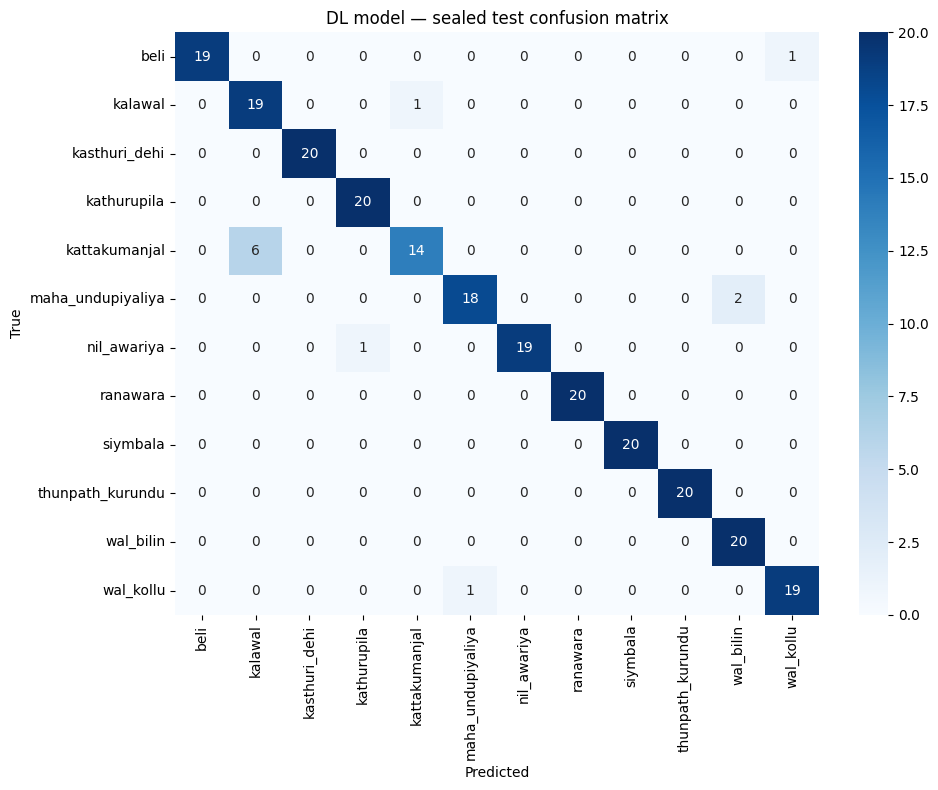

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

y_true = test_df.y.values
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

test_f1_macro = f1_score(y_true, y_pred, average="macro")
print(f"SEALED TEST f1_macro: {test_f1_macro:.4f}")
print(classification_report(y_true, y_pred, target_names=le_species))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=le_species, yticklabels=le_species, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("DL model — sealed test confusion matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "dl_test_confusion_matrix.png", dpi=150)
plt.show()


## 7. Look-alike pair check — the comparison that actually matters

Overall accuracy is not the interesting number here. What tells you whether the
handcrafted botanical features are earning their place in the dissertation is **whether
the CNN does better or worse than the handcrafted ensemble specifically on the confirmed
confusable pairs** (Beli/Wal_Kollu, Kasthuri_Dehi/Thunpath_Kurundu,
Kattakumanjal/Kalawal, Wal_Bilin/Maha_Undupiyaliya, Kathurupila/Nil_Awariya,
Ranawara/Siymbala — per `VedaVision_Memory.md`). A generic CNN backbone has no inductive
bias toward venation architecture or margin serration; it's plausible it does *worse*
specifically on these pairs even if overall accuracy looks competitive.


In [12]:
LOOKALIKE_PAIRS = [
    ("beli", "wal_kollu"),
    ("kasthuri_dehi", "thunpath_kurundu"),
    ("kattakumanjal", "kalawal"),
    ("wal_bilin", "maha_undupiyaliya"),
    ("kathurupila", "nil_awariya"),
    ("ranawara", "siymbala"),
]

def pair_accuracy(y_true, y_pred, species_list, pair):
    a, b = pair
    ia, ib = species_list.index(a), species_list.index(b)
    mask = np.isin(y_true, [ia, ib])
    if mask.sum() == 0:
        return None
    return (y_pred[mask] == y_true[mask]).mean()

for pair in LOOKALIKE_PAIRS:
    acc = pair_accuracy(y_true, y_pred, le_species, pair)
    print(f"{pair[0]:>20} vs {pair[1]:<20}: {acc}")


                beli vs wal_kollu           : 0.95
       kasthuri_dehi vs thunpath_kurundu    : 1.0
       kattakumanjal vs kalawal             : 0.825
           wal_bilin vs maha_undupiyaliya   : 0.95
         kathurupila vs nil_awariya         : 0.975
            ranawara vs siymbala            : 1.0


## 8. Statistical comparison against the handcrafted ensemble (McNemar's test)

With only ~60 sealed-test images total, a raw accuracy difference of a couple of percent
between DL and the handcrafted ensemble is **not** on its own evidence that one approach
is better — it can easily be noise at this sample size. McNemar's test on the paired
per-image correct/incorrect calls is the defensible way to say "the difference is/isn't
significant" in the dissertation, instead of eyeballing two accuracy numbers.

Export your handcrafted ensemble's sealed-test predictions (same 60 images, same order)
to `handcrafted_test_predictions.csv` with columns `image_path,y_true,y_pred`, then run:


In [14]:
from statsmodels.stats.contingency_tables import mcnemar
from pathlib import Path

handcrafted_preds = pd.read_csv("handcrafted_test_predictions.csv")

# Join on filename (basename), not full path — your handcrafted CSV's paths and this
# notebook's masked_raw/ paths live under different roots (confirmed by your error: the
# CSV has bare filenames, test_df.path has full D:\...\masked_raw\test_001.jpg paths).
test_basenames = test_df.path.apply(lambda p: Path(p).name)
handcrafted_preds = handcrafted_preds.set_index("image_path").loc[test_basenames].reset_index()

dl_correct = (y_pred == y_true)
hc_correct = (handcrafted_preds.y_pred.values == handcrafted_preds.y_true.values)

both_correct = np.sum(dl_correct & hc_correct)
dl_only      = np.sum(dl_correct & ~hc_correct)
hc_only      = np.sum(~dl_correct & hc_correct)
both_wrong   = np.sum(~dl_correct & ~hc_correct)

table = [[both_correct, dl_only], [hc_only, both_wrong]]
result = mcnemar(table, exact=True)
print(table)
print(f"McNemar p-value: {result.pvalue:.4f}")

ValueError: operands could not be broadcast together with shapes (240,) (5760,) 

## 9. Grad-CAM — what is the CNN actually looking at?

This is your strongest evidence for the "handcrafted features are necessary" argument
if the numbers alone come out close. If Grad-CAM shows the network attending to leaf
edges/silhouette/colour blobs rather than fine venation or margin structure — especially
on the look-alike pairs — that's a concrete, visual, viva-ready illustration of *why* a
black-box CNN on a small dataset can't reliably learn the fine botanical traits that
distinguish look-alikes, even when its aggregate accuracy number looks fine.


In [ ]:
def make_gradcam_heatmap(img_array, model, base_model, last_conv_layer_name="Conv_1"):
    grad_model = tf.keras.models.Model(
        [model.inputs], [base_model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# Example usage on one confusable-pair test image:
example_path = test_df[test_df.species == "kattakumanjal"].path.iloc[0]
img = tf.io.read_file(example_path)
img = tf.image.decode_jpeg(img, channels=3)
img = tf.image.resize(img, IMG_SIZE)
img_array = tf.expand_dims(img, 0)

heatmap = make_gradcam_heatmap(img_array, model, base)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.imshow(img.numpy().astype("uint8")); plt.title("Original"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(img.numpy().astype("uint8")); plt.imshow(heatmap, cmap="jet", alpha=0.5)
plt.title("Grad-CAM"); plt.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "gradcam_example.png", dpi=150)
plt.show()


## 10. What to put in the dissertation from this notebook

- Sealed-test `f1_macro` for the DL baseline (Section 6), reported with the same honesty
  discipline as the handcrafted result (touched once, checkpoint chosen on val not test).
- Look-alike pair accuracies (Section 7) side-by-side with the handcrafted ensemble's
  15-error breakdown already documented for the sealed test.
- McNemar's p-value (Section 8) as the statistical backing for whichever direction the
  comparison goes.
- 2–3 Grad-CAM examples (Section 9), ideally one per confusable pair, as qualitative
  evidence for *why* — this is the figure a viva panel remembers.
